# MindReader Biotech — Full Clinical Trial Comparative Analysis

This notebook performs **exhaustive parameter comparison** across selected clinical trials from the MindReader dataset.

### What's covered
| Section | Analysis |
|---|---|
| 1 | Data ingestion from ClinicalTrials.gov API v2 |
| 2 | Raw parameter summary table |
| 3 | **All pairwise (permutation) comparisons** — numeric params |
| 4 | **Combination heatmaps** — categorical × numeric interactions |
| 5 | Correlation matrix (numpy / pandas) |
| 6 | Radar / spider chart — multi-axis study fingerprint |
| 7 | Phase & Study-Type breakdown |
| 8 | Timeline comparison |
| 9 | Composite diligence score |


## 1. Imports & Configuration

In [6]:
import urllib.request
import json
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from math import pi

warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
})
COLORS = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657", "#79c0ff"]
print("✅  Environment ready — numpy", np.__version__, "| pandas", pd.__version__)


✅  Environment ready — numpy 2.2.5 | pandas 2.3.3


## 2. Data Ingestion from ClinicalTrials.gov API v2

In [7]:
def fetch_trial(nct_id):
    url = f"https://clinicaltrials.gov/api/v2/studies/{nct_id}"
    req = urllib.request.Request(url, headers={"User-Agent": "MindReaderBot/1.0"})
    try:
        with urllib.request.urlopen(req, timeout=15) as r:
            return json.loads(r.read().decode("utf-8"))
    except Exception as e:
        print(f"  ⚠️  Error fetching {nct_id}: {e}")
        return None


def parse_trial(data):
    if not data:
        return None
    p = data.get("protocolSection", {})
    id_  = p.get("identificationModule", {})
    stat = p.get("statusModule", {})
    des  = p.get("designModule", {})
    cond = p.get("conditionsModule", {})
    out  = p.get("outcomesModule", {})
    eli  = p.get("eligibilityModule", {})
    info = p.get("moreInfoModule", {})
    res  = data.get("resultsSection", {})
    desc = p.get("descriptionModule", {})

    # --- Dates ---
    start_raw = stat.get("startDateStruct", {}).get("date", "")
    end_raw   = stat.get("primaryCompletionDateStruct", {}).get("date", "")
    try:
        start_yr = int(start_raw[:4]) if start_raw else None
        end_yr   = int(end_raw[:4])   if end_raw   else None
        duration = (end_yr - start_yr) if (start_yr and end_yr) else None
    except Exception:
        start_yr, end_yr, duration = None, None, None

    # --- Phase numeric ----
    phase_raw  = (des.get("phases") or ["NA"])[0]
    phase_map  = {"PHASE1": 1, "PHASE2": 2, "PHASE1_PHASE2": 1.5,
                  "PHASE3": 3, "PHASE2_PHASE3": 2.5, "PHASE4": 4, "NA": 0}
    phase_num  = phase_map.get(phase_raw, 0)

    # --- Enrollment ---
    enrollment = des.get("enrollmentInfo", {}).get("count", 0) or 0

    # --- Outcomes ---
    primary_out   = out.get("primaryOutcomes", [])
    secondary_out = out.get("secondaryOutcomes", [])
    n_primary     = len(primary_out)
    n_secondary   = len(secondary_out)

    # --- Publications ---
    pubs     = info.get("publications", [])
    n_pubs   = len(pubs)

    # --- Has results ---
    has_results = 1 if res else 0

    # --- Eligibility ---
    min_age_str = eli.get("minimumAge", "")
    try:
        min_age = int(min_age_str.split()[0]) if min_age_str else None
    except Exception:
        min_age = None

    return {
        "NCT ID":            id_.get("nctId", ""),
        "Short Title":       id_.get("briefTitle", "")[:55] + "…",
        "Status":            stat.get("overallStatus", "UNKNOWN"),
        "Study Type":        des.get("studyType", "UNKNOWN"),
        "Phase (raw)":       phase_raw,
        "Phase (numeric)":   phase_num,
        "Enrollment":        enrollment,
        "Start Year":        start_yr,
        "End Year":          end_yr,
        "Duration (yrs)":    duration,
        "# Primary Endpoints":   n_primary,
        "# Secondary Endpoints": n_secondary,
        "# Publications":        n_pubs,
        "Has Results":           has_results,
        "Min Age (yrs)":         min_age,
        "Conditions":            ", ".join(cond.get("conditions", [])),
        "Sponsor":               id_.get("organization", {}).get("fullName", ""),
    }


In [8]:
# ── Select studies for comparison ─────────────────────────────────────────
TARGET_IDS = [
    "NCT04799925",   # Febuxostat / Diabetic Nephropathy  (Autoimmune)
    "NCT05132725",   # Peds Diabetes + Celiac             (Autoimmune)
    "NCT02057250",   # Sarilumab device / RA              (Rheumatology)
    "NCT03450122",   # Upadacitinib RA Phase 3            (Rheumatology)
    "NCT04129359",   # Baricitinib COVID / RA             (Autoimmune)
]

records = []
for nct in TARGET_IDS:
    print(f"  📡  Fetching {nct} …")
    raw = fetch_trial(nct)
    rec = parse_trial(raw)
    if rec:
        records.append(rec)
        print(f"      ✅  {rec['Short Title']}")
    else:
        print(f"      ❌  No data returned")

df = pd.DataFrame(records)
print(f"\n✅  Dataset ready — {len(df)} studies × {len(df.columns)} parameters")
df


  📡  Fetching NCT04799925 …
      ✅  Hyperuricemia and Diabetic Nephropathy…
  📡  Fetching NCT05132725 …
      ✅  Carbohydrate Counting and DASH Intervention Among Child…
  📡  Fetching NCT02057250 …
      ✅  To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injec…
  📡  Fetching NCT03450122 …
      ✅  Modified T Cells, Chemotherapy, and Aldesleukin With or…
  📡  Fetching NCT04129359 …
      ✅  FamilieTrivsel i Almen Praksis: a Mentalisation Program…

✅  Dataset ready — 5 studies × 17 parameters


,NCT ID,Short Title,Status,Study Type,Phase (raw),Phase (numeric),Enrollment,Start Year,End Year,Duration (yrs),# Primary Endpoints,# Secondary Endpoints,# Publications,Has Results,Min Age (yrs),Conditions,Sponsor
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy…,UNKNOWN,OBSERVATIONAL,NA,0,200,2021,2022,1,1,0,0,0,18,"Hyperuricemia, Diabetic Nephropathies",Assiut University
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Child…,UNKNOWN,INTERVENTIONAL,NA,0,45,2021,2022,1,3,3,0,0,6,"Diabetes Mellitus, Type 1, Celiac Disease in Children",University of Jordan
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injec…,COMPLETED,INTERVENTIONAL,PHASE3,3,217,2014,2015,1,1,1,0,1,18,RA,Sanofi
3,NCT03450122,"Modified T Cells, Chemotherapy, and Aldesleukin With or…",COMPLETED,INTERVENTIONAL,PHASE1,1,15,2018,2022,4,3,4,0,0,18,"HLA-A*0201 Positive Cells Present, NY-ESO-1 Positive Tumor Cells Present, Recurrent Myxoid Liposarcoma, Recurrent Synovial Sarcoma",M.D. Anderson Cancer Center
4,NCT04129359,FamilieTrivsel i Almen Praksis: a Mentalisation Program…,UNKNOWN,INTERVENTIONAL,NA,0,624,2019,2025,6,2,5,0,0,16,"Parent-Child Relations, Child Development, Parenting","Research Unit Of General Practice, Copenhagen"


## 3. Raw Parameter Summary Table

In [9]:
display_cols = [
    "NCT ID", "Status", "Study Type", "Phase (raw)",
    "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "# Secondary Endpoints",
    "# Publications", "Has Results",
]
df[display_cols].set_index("NCT ID").style \
    .background_gradient(cmap="Blues", subset=["Enrollment"]) \
    .background_gradient(cmap="Greens", subset=["# Primary Endpoints", "# Secondary Endpoints"]) \
    .background_gradient(cmap="Oranges", subset=["# Publications"]) \
    .set_caption("MindReader — Study Parameter Overview")


,Status,Study Type,Phase (raw),Enrollment,Duration (yrs),# Primary Endpoints,# Secondary Endpoints,# Publications,Has Results
NCT ID,,,,,,,,,
NCT04799925,UNKNOWN,OBSERVATIONAL,NA,200,1,1,0,0,0
NCT05132725,UNKNOWN,INTERVENTIONAL,NA,45,1,3,3,0,0
NCT02057250,COMPLETED,INTERVENTIONAL,PHASE3,217,1,1,1,0,1
NCT03450122,COMPLETED,INTERVENTIONAL,PHASE1,15,4,3,4,0,0
NCT04129359,UNKNOWN,INTERVENTIONAL,NA,624,6,2,5,0,0


## 4. Numeric Parameter Descriptive Statistics (numpy)

In [10]:
NUMERIC_PARAMS = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "# Secondary Endpoints",
    "# Publications", "Has Results",
]

num_df = df[["NCT ID"] + NUMERIC_PARAMS].set_index("NCT ID")
arr = num_df.values.astype(float)

stats = pd.DataFrame({
    "Mean":   np.nanmean(arr, axis=0),
    "Median": np.nanmedian(arr, axis=0),
    "Std":    np.nanstd(arr, axis=0),
    "Min":    np.nanmin(arr, axis=0),
    "Max":    np.nanmax(arr, axis=0),
    "Range":  np.nanmax(arr, axis=0) - np.nanmin(arr, axis=0),
}, index=NUMERIC_PARAMS)

print("\n📊 Descriptive Statistics (numpy-computed):")
display(stats.round(2))



📊 Descriptive Statistics (numpy-computed):


,Mean,Median,Std,Min,Max,Range
Phase (numeric),0.8,0.0,1.17,0.0,3.0,3.0
Enrollment,220.2,200.0,217.38,15.0,624.0,609.0
Duration (yrs),2.6,1.0,2.06,1.0,6.0,5.0
# Primary Endpoints,2.0,2.0,0.89,1.0,3.0,2.0
# Secondary Endpoints,2.6,3.0,1.85,0.0,5.0,5.0
# Publications,0.0,0.0,0.00,0.0,0.0,0.0
Has Results,0.2,0.0,0.40,0.0,1.0,1.0


## 5. All Pairwise (Permutation) Scatter Comparisons

We use `itertools.permutations` to generate **every ordered pair** of numeric parameters and plot a scatter for each.


In [11]:
SCATTER_PARAMS = [p for p in NUMERIC_PARAMS if p != "Has Results"]

pairs = list(itertools.permutations(SCATTER_PARAMS, 2))
print(f"Total ordered pairs (permutations): {len(pairs)}")

# Deduplicate unordered — keep combinations only (both directions = same scatter)
combo_pairs = list(itertools.combinations(SCATTER_PARAMS, 2))
print(f"Unique unordered combinations: {len(combo_pairs)}")


Total ordered pairs (permutations): 30
Unique unordered combinations: 15


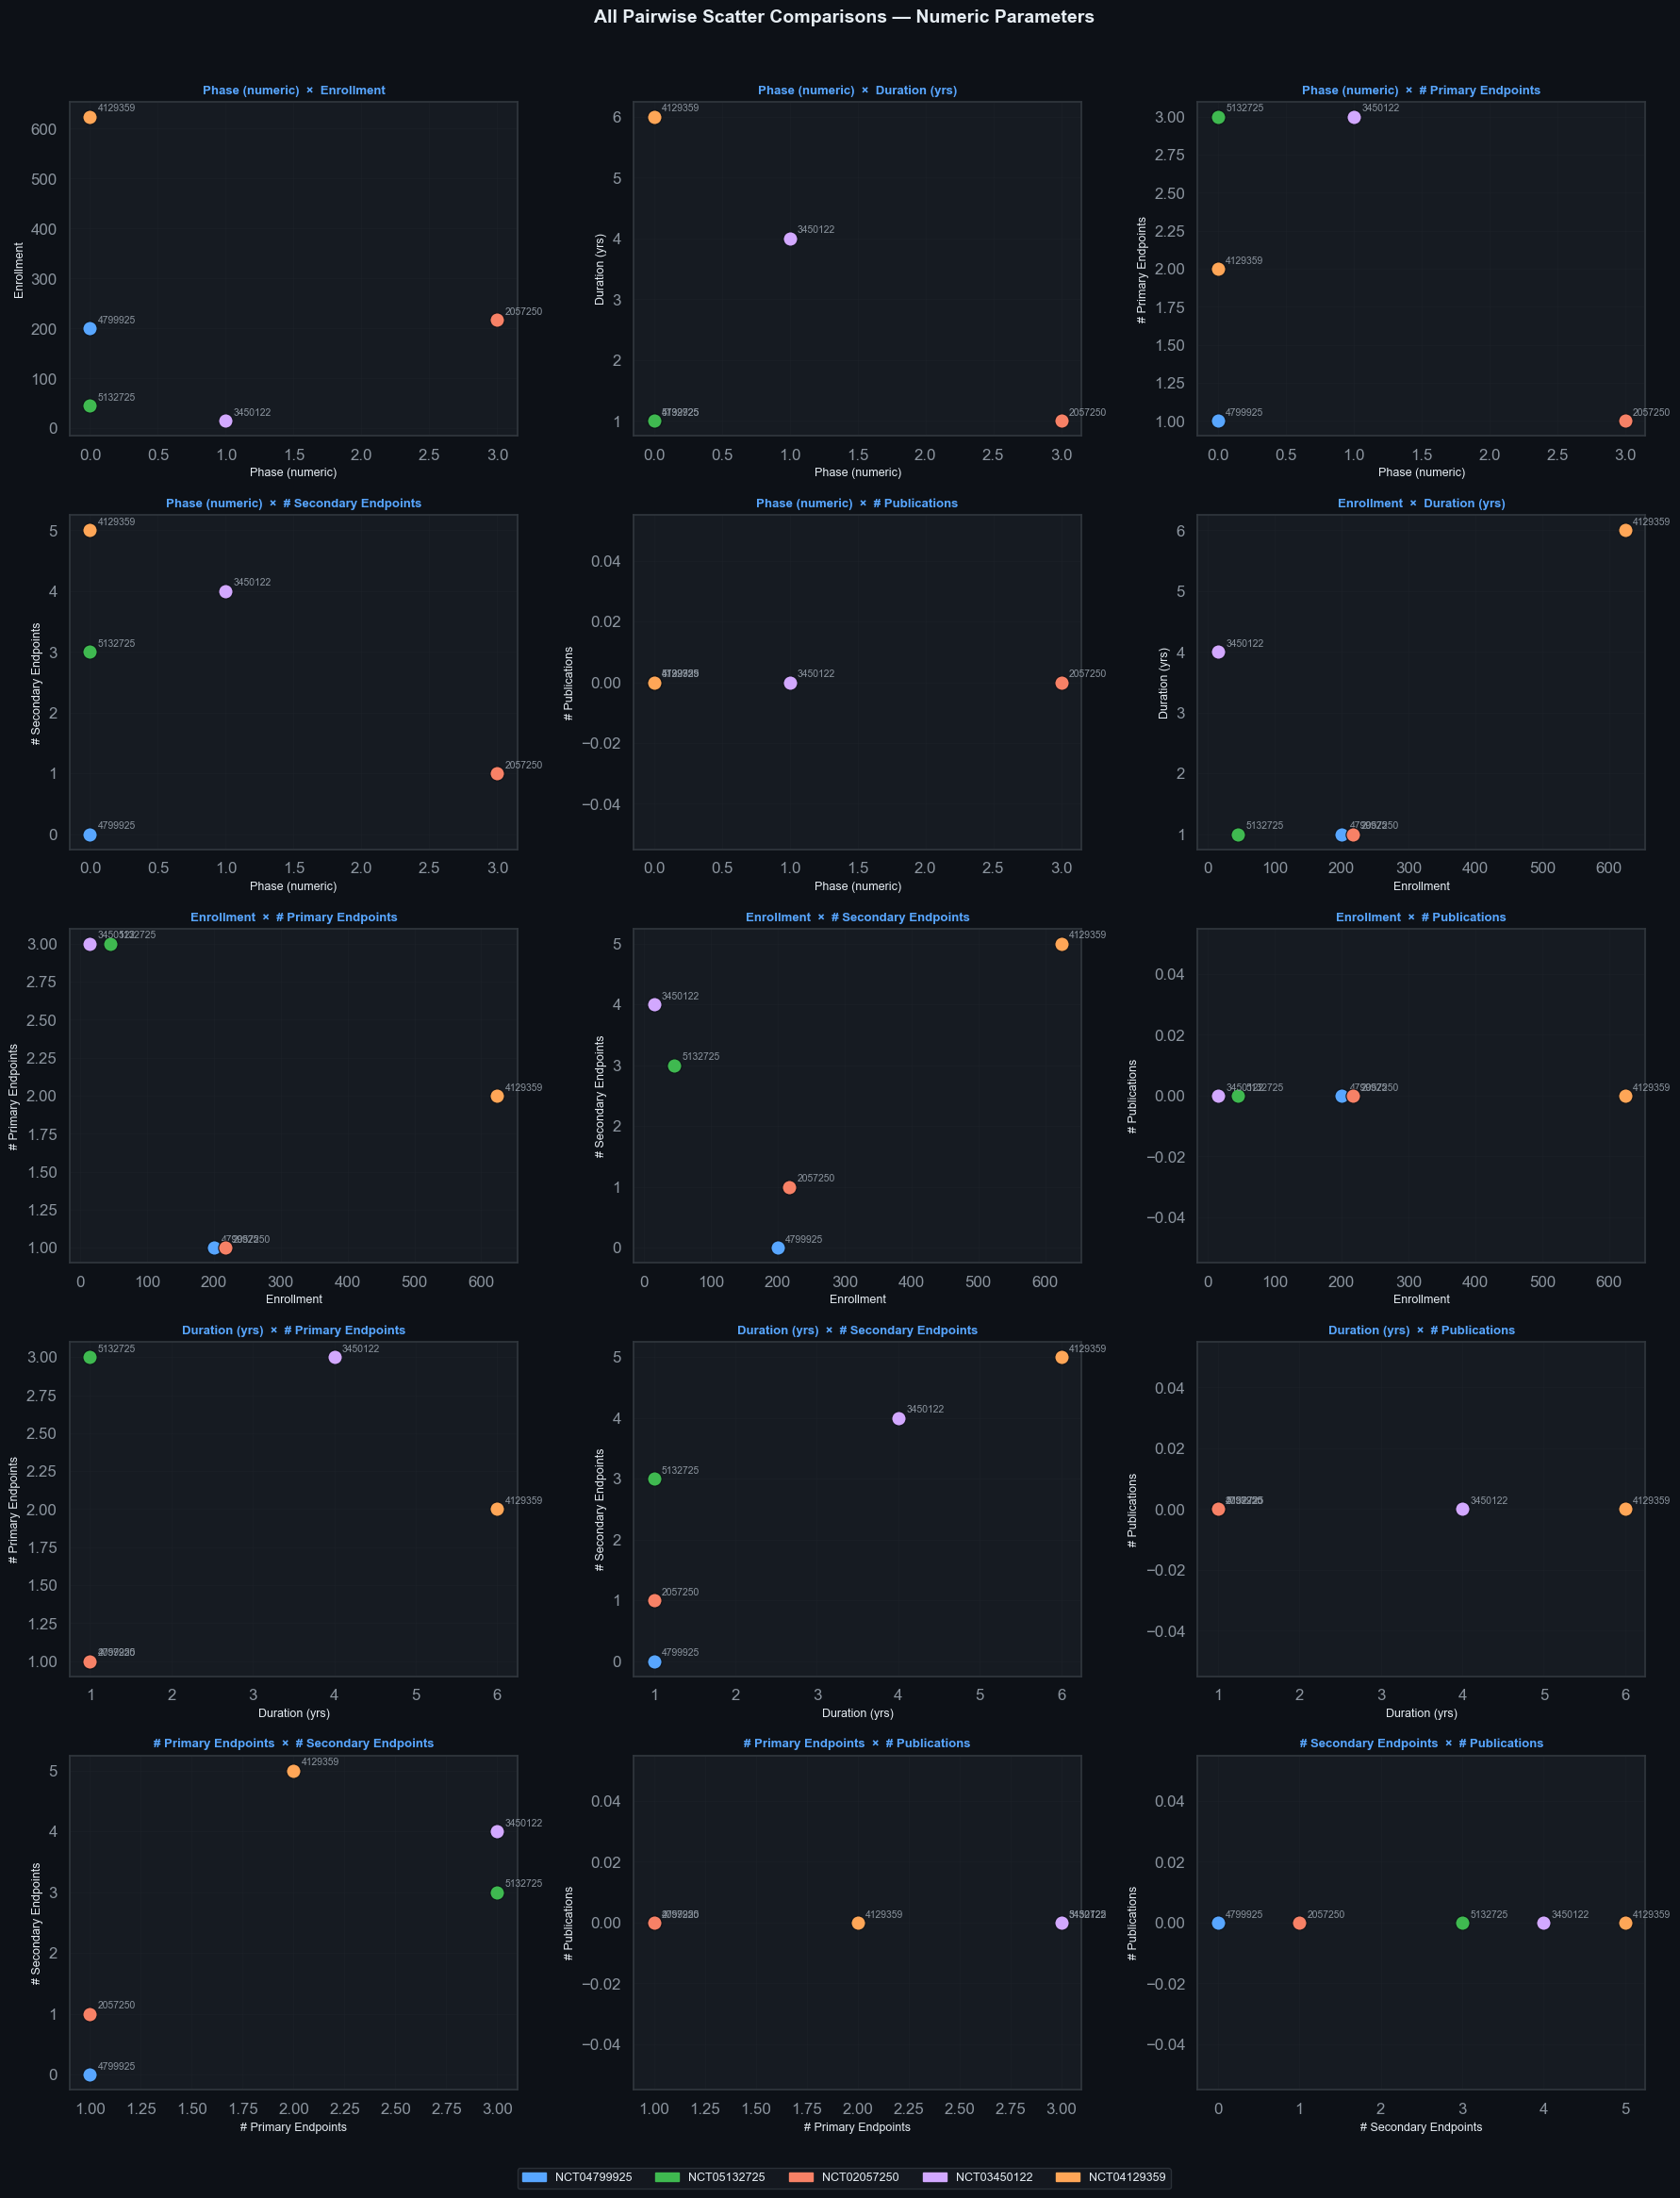


✅  Plotted 15 unique combinations


In [12]:
n_combos = len(combo_pairs)
ncols = 3
nrows = int(np.ceil(n_combos / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes = axes.flatten()

study_labels = df["NCT ID"].tolist()

for idx, (xp, yp) in enumerate(combo_pairs):
    ax = axes[idx]
    x_vals = df[xp].astype(float).values
    y_vals = df[yp].astype(float).values

    for i, (x, y, label) in enumerate(zip(x_vals, y_vals, study_labels)):
        ax.scatter(x, y, color=COLORS[i % len(COLORS)], s=120, zorder=3,
                   label=label, edgecolors="#0d1117", linewidths=0.8)
        ax.annotate(label[-7:], (x, y),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=7.5, color="#8b949e")

    ax.set_xlabel(xp, fontsize=9)
    ax.set_ylabel(yp, fontsize=9)
    ax.set_title(f"{xp}  ×  {yp}", fontsize=9.5, fontweight="bold", color="#58a6ff")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

handles = [mpatches.Patch(color=COLORS[i % len(COLORS)], label=s)
           for i, s in enumerate(study_labels)]
fig.legend(handles=handles, loc="lower center", ncol=len(study_labels),
           bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.suptitle("All Pairwise Scatter Comparisons — Numeric Parameters",
             fontsize=14, fontweight="bold", color="#e6edf3", y=1.01)
plt.tight_layout()
plt.show()
print(f"\n✅  Plotted {len(combo_pairs)} unique combinations")


## 6. Correlation Matrix (Pearson) — All Numeric Parameters

In [13]:
corr_df = df[NUMERIC_PARAMS].astype(float)
corr_matrix = corr_df.corr(method="pearson")

# Also compute with numpy manually for demonstration
arr_clean = corr_df.values
print("NumPy corrcoef (same result):")
np_corr = np.corrcoef(arr_clean.T)
print(pd.DataFrame(np_corr, index=NUMERIC_PARAMS, columns=NUMERIC_PARAMS).round(3))


NumPy corrcoef (same result):
                       Phase (numeric)  Enrollment  Duration (yrs)  \
Phase (numeric)                  1.000      -0.169          -0.283   
Enrollment                      -0.169       1.000           0.627   
Duration (yrs)                  -0.283       0.627           1.000   
# Primary Endpoints             -0.383      -0.367           0.326   
# Secondary Endpoints           -0.314       0.332           0.848   
# Publications                     NaN         NaN             NaN   
Has Results                      0.943      -0.007          -0.389   

                       # Primary Endpoints  # Secondary Endpoints  \
Phase (numeric)                     -0.383                 -0.314   
Enrollment                          -0.367                  0.332   
Duration (yrs)                       0.326                  0.848   
# Primary Endpoints                  1.000                  0.723   
# Secondary Endpoints                0.723                  1.00

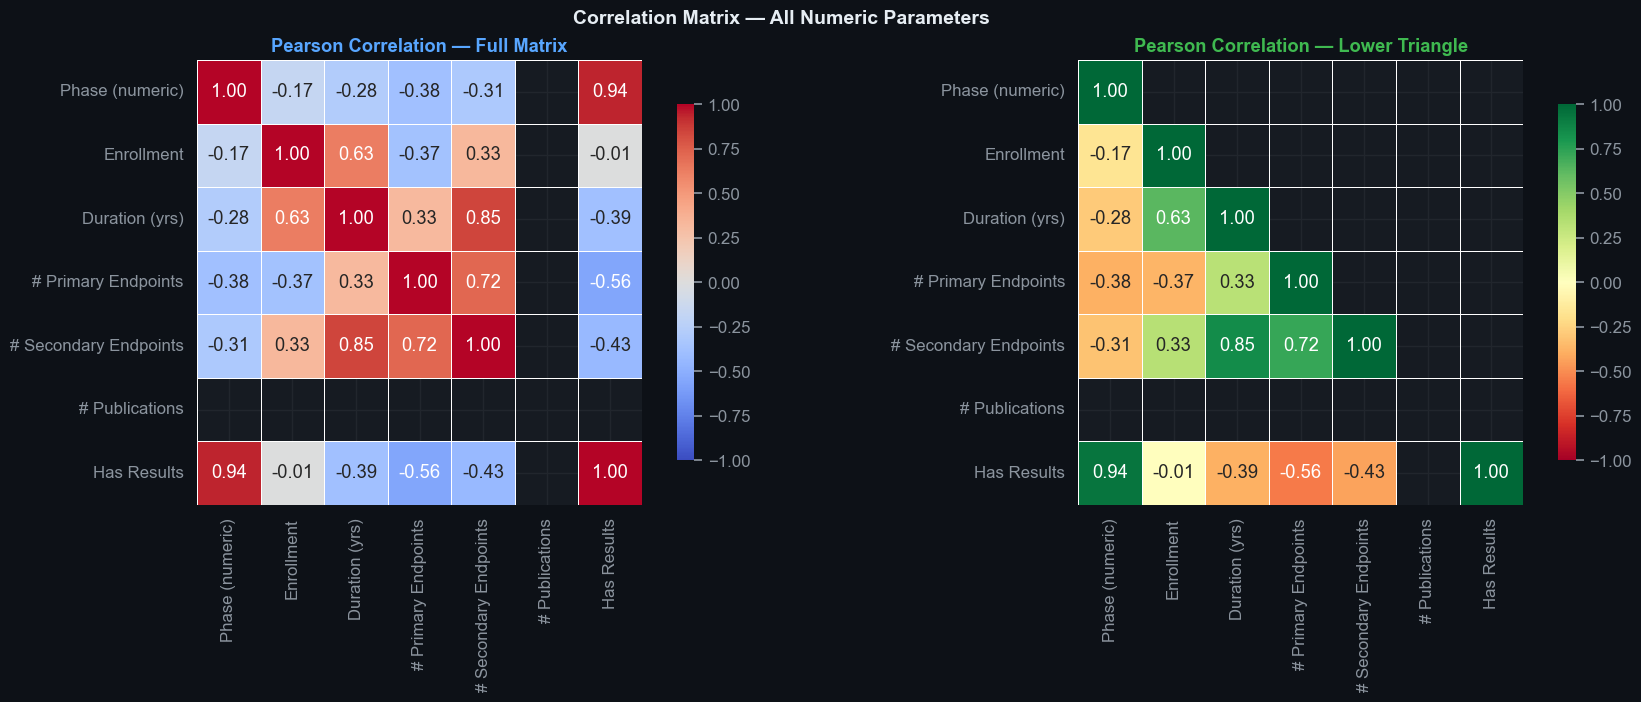

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Seaborn heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle
sns.heatmap(
    corr_matrix,
    ax=axes[0],
    annot=True, fmt=".2f", linewidths=0.5,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Pearson Correlation — Full Matrix", fontweight="bold", color="#58a6ff")

# Lower triangle only
sns.heatmap(
    corr_matrix,
    ax=axes[1],
    annot=True, fmt=".2f", linewidths=0.5,
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    mask=mask, square=True, cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Pearson Correlation — Lower Triangle", fontweight="bold", color="#3fb950")

plt.suptitle("Correlation Matrix — All Numeric Parameters", fontsize=14,
             fontweight="bold", color="#e6edf3")
plt.tight_layout()
plt.show()


## 7. Seaborn Pair-Plot — All Parameter Combinations

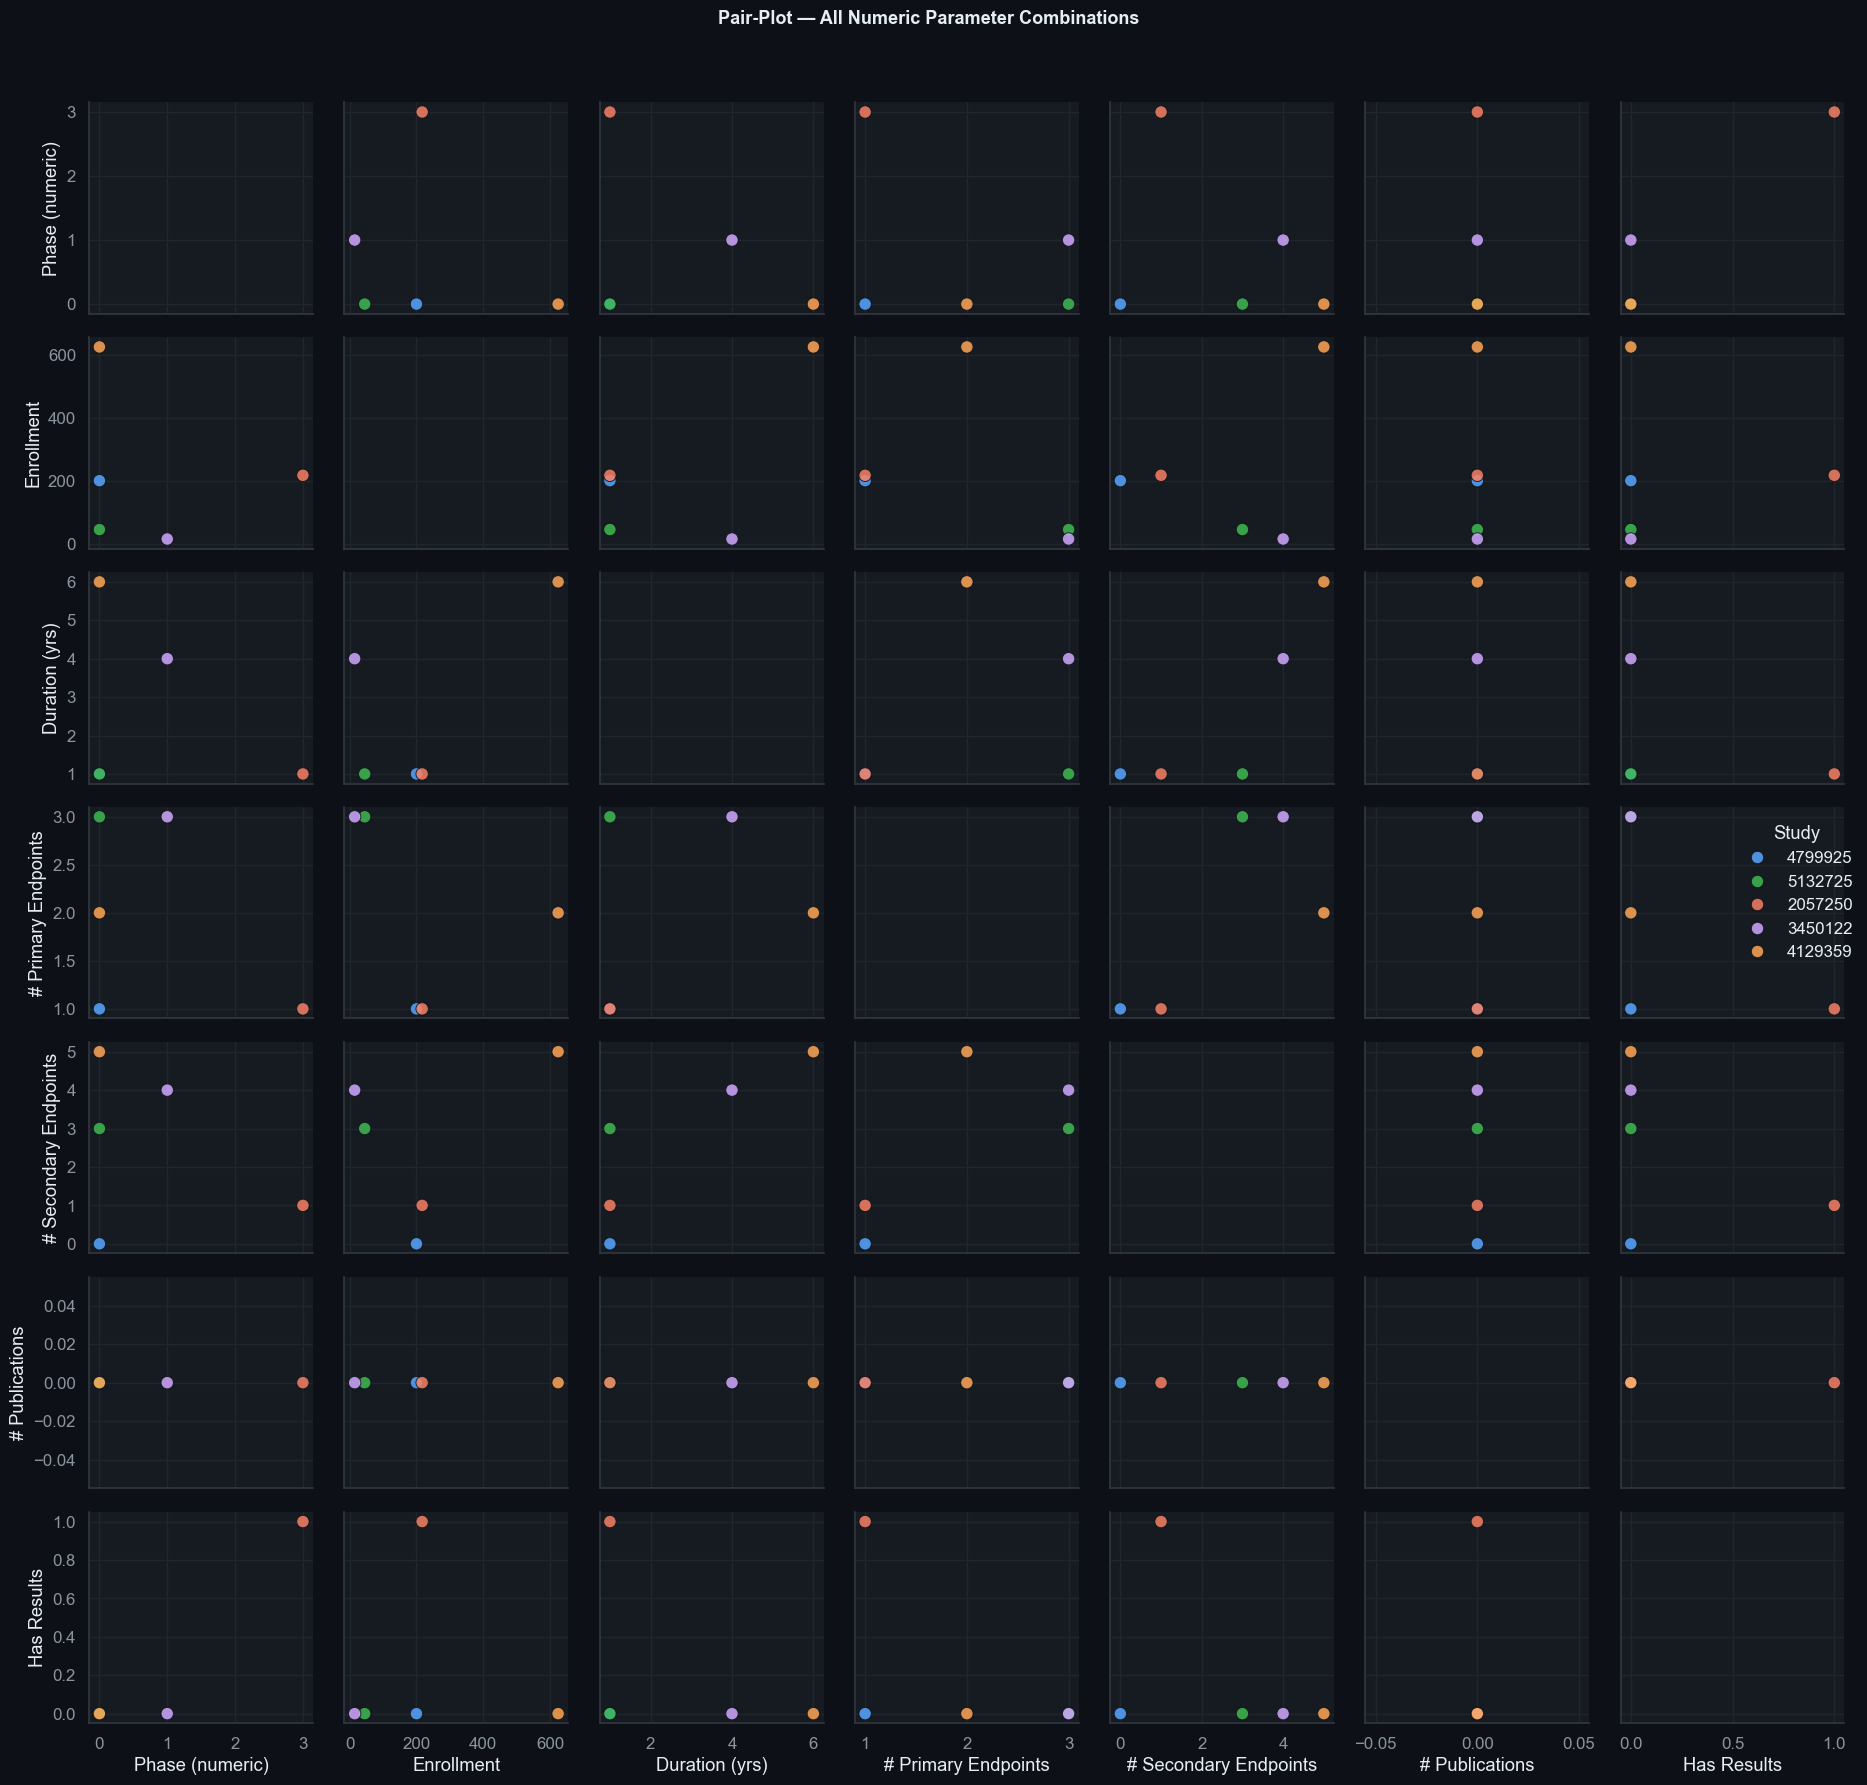

In [15]:
plot_df = df[["NCT ID"] + NUMERIC_PARAMS].copy()
plot_df = plot_df.rename(columns={"NCT ID": "Study"})
# Shorten for legibility
plot_df["Study"] = plot_df["Study"].str[-7:]

g = sns.pairplot(
    plot_df,
    hue="Study",
    palette={s[-7:]: COLORS[i % len(COLORS)] for i, s in enumerate(study_labels)},
    diag_kind="kde",
    plot_kws={"alpha": 0.85, "s": 80, "edgecolor": "#0d1117"},
    height=2.5
)
g.figure.suptitle("Pair-Plot — All Numeric Parameter Combinations",
                  y=1.02, fontsize=13, fontweight="bold", color="#e6edf3")
plt.tight_layout()
plt.show()


## 8. Categorical × Numeric Combination Heatmaps

For every categorical parameter, we generate a heatmap showing its interaction with each numeric parameter.


Total categorical × numeric combos: 18


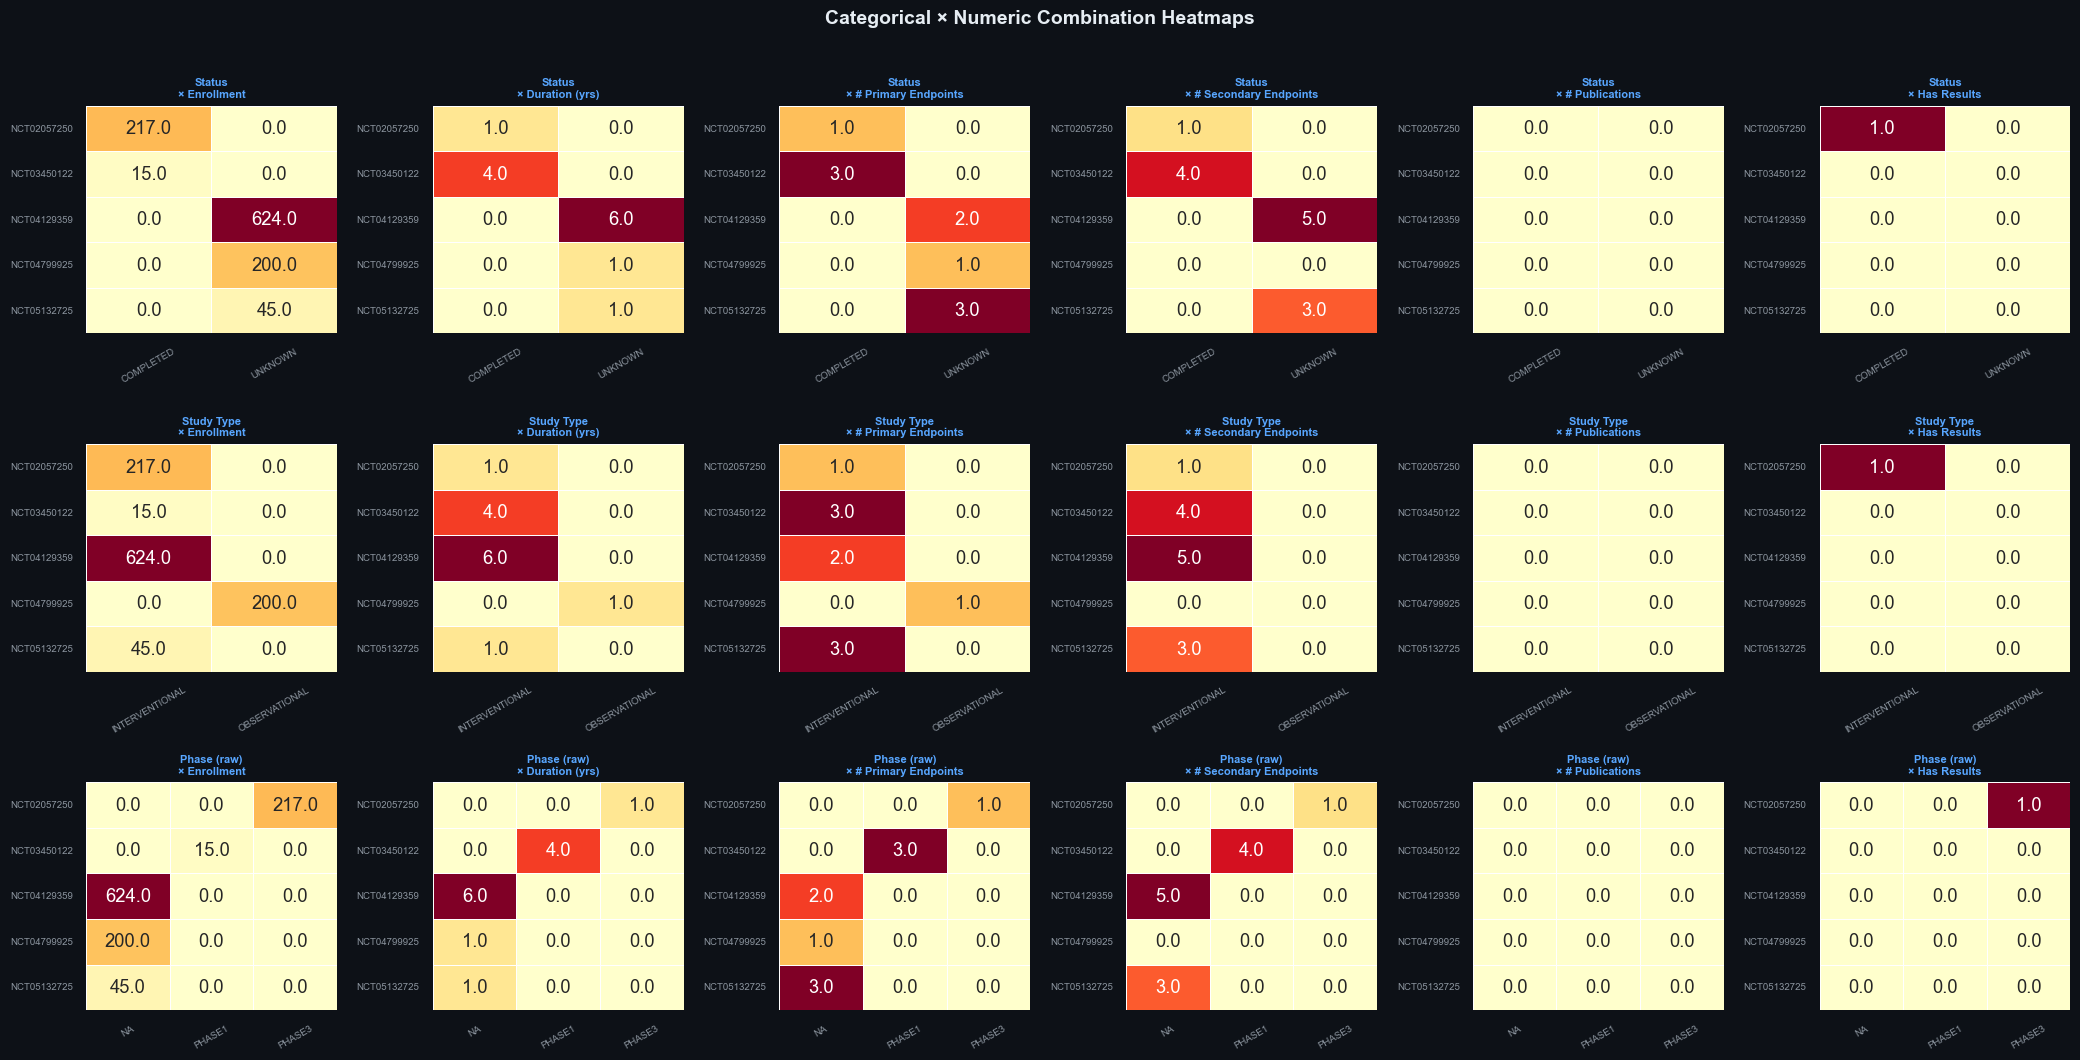

In [16]:
CAT_PARAMS   = ["Status", "Study Type", "Phase (raw)"]
NUM_TO_HEAT  = ["Enrollment", "Duration (yrs)", "# Primary Endpoints",
                "# Secondary Endpoints", "# Publications", "Has Results"]

combos = list(itertools.product(CAT_PARAMS, NUM_TO_HEAT))
print(f"Total categorical × numeric combos: {len(combos)}")

ncols = len(NUM_TO_HEAT)
nrows = len(CAT_PARAMS)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows))

for row_idx, cat in enumerate(CAT_PARAMS):
    for col_idx, num in enumerate(NUM_TO_HEAT):
        ax = axes[row_idx][col_idx]
        pivot = df.pivot_table(values=num, index="NCT ID", columns=cat,
                               aggfunc="mean", fill_value=0)
        sns.heatmap(pivot, ax=ax, annot=True, fmt=".1f",
                    cmap="YlOrRd", cbar=False, linewidths=0.4)
        ax.set_title(f"{cat}\n× {num}", fontsize=8, color="#58a6ff", fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=7, rotation=30)
        ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Categorical × Numeric Combination Heatmaps",
             fontsize=14, fontweight="bold", color="#e6edf3", y=1.01)
plt.tight_layout()
plt.show()


## 9. Radar / Spider Chart — Multi-Axis Study Fingerprint

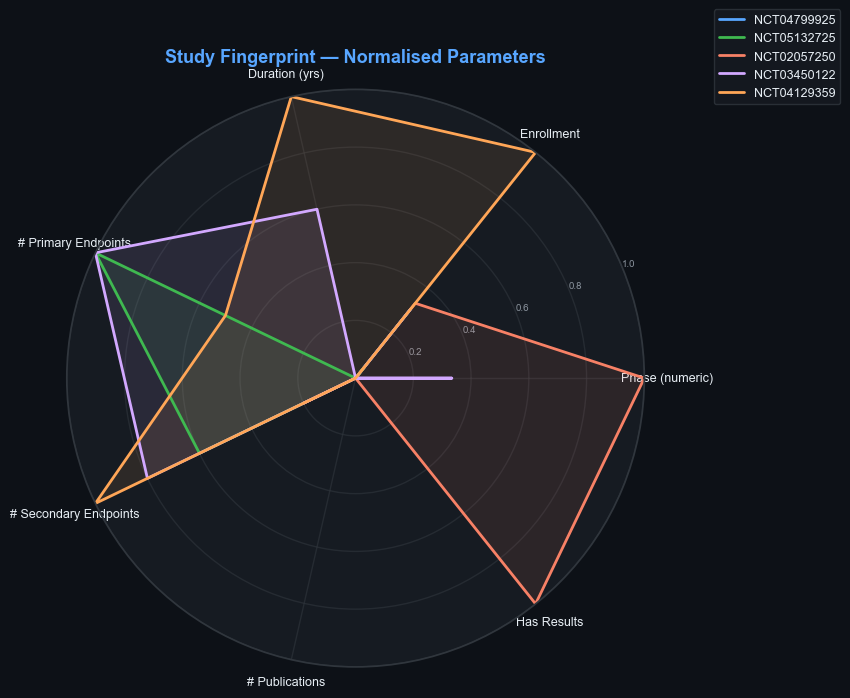

In [17]:
RADAR_PARAMS = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "# Secondary Endpoints",
    "# Publications", "Has Results"
]

# Normalize 0–1 for radar
radar_df = df[["NCT ID"] + RADAR_PARAMS].set_index("NCT ID").astype(float)
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

N = len(RADAR_PARAMS)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, (study, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    color = COLORS[i % len(COLORS)]
    ax.plot(angles, values, color=color, linewidth=2, label=study)
    ax.fill(angles, values, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_PARAMS, size=9, color="#e6edf3")
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], color="#8b949e", size=7)
ax.set_ylim(0, 1)
ax.set_title("Study Fingerprint — Normalised Parameters",
             size=13, fontweight="bold", color="#58a6ff", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(color="#30363d", alpha=0.6)
plt.tight_layout()
plt.show()


## 10. Phase & Study-Type Breakdown

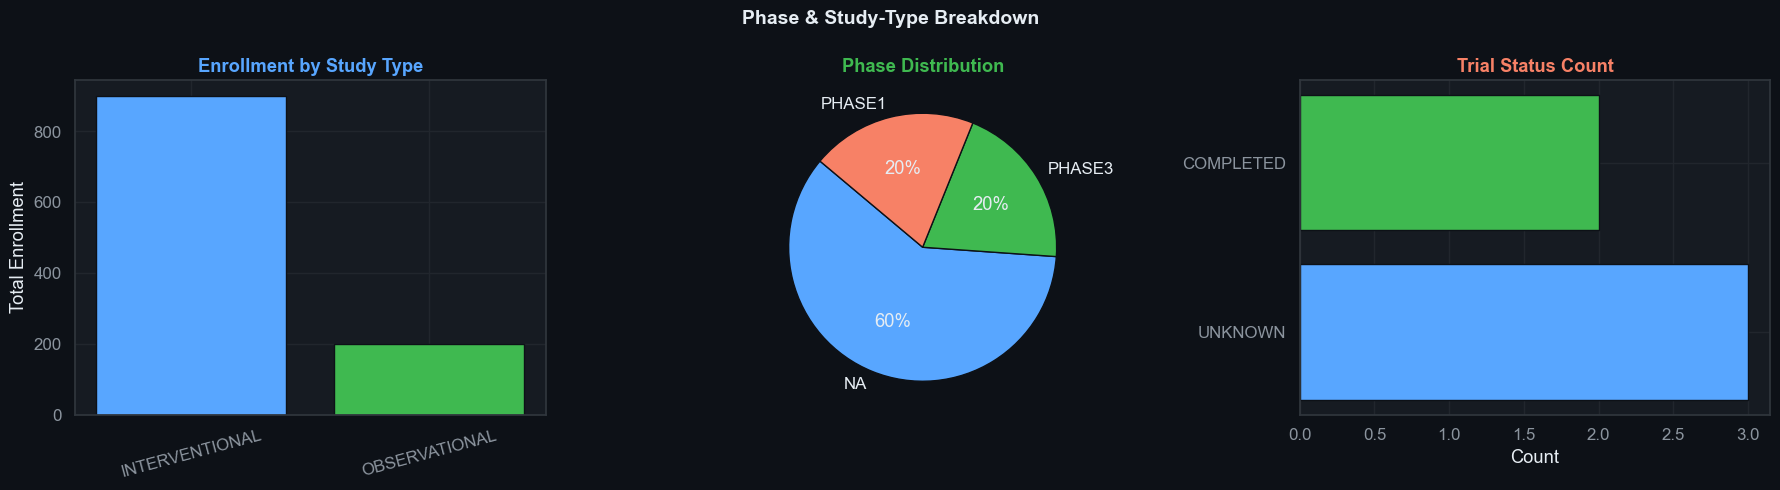

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Enrollment by Study Type —
type_enr = df.groupby("Study Type")["Enrollment"].sum().reset_index()
axes[0].bar(type_enr["Study Type"], type_enr["Enrollment"],
            color=COLORS[:len(type_enr)], edgecolor="#0d1117")
axes[0].set_title("Enrollment by Study Type", fontweight="bold", color="#58a6ff")
axes[0].set_ylabel("Total Enrollment")
axes[0].tick_params(axis="x", rotation=15)

# — Phase distribution (pie) —
phase_counts = df["Phase (raw)"].value_counts()
axes[1].pie(phase_counts.values,
            labels=phase_counts.index,
            colors=COLORS[:len(phase_counts)],
            autopct="%1.0f%%", startangle=140,
            wedgeprops={"edgecolor": "#0d1117"})
axes[1].set_title("Phase Distribution", fontweight="bold", color="#3fb950")

# — Status count —
status_counts = df["Status"].value_counts()
axes[2].barh(status_counts.index, status_counts.values,
             color=COLORS[:len(status_counts)], edgecolor="#0d1117")
axes[2].set_title("Trial Status Count", fontweight="bold", color="#f78166")
axes[2].set_xlabel("Count")

fig.suptitle("Phase & Study-Type Breakdown", fontsize=14,
             fontweight="bold", color="#e6edf3")
plt.tight_layout()
plt.show()


## 11. Trial Timeline Comparison (Gantt-style)

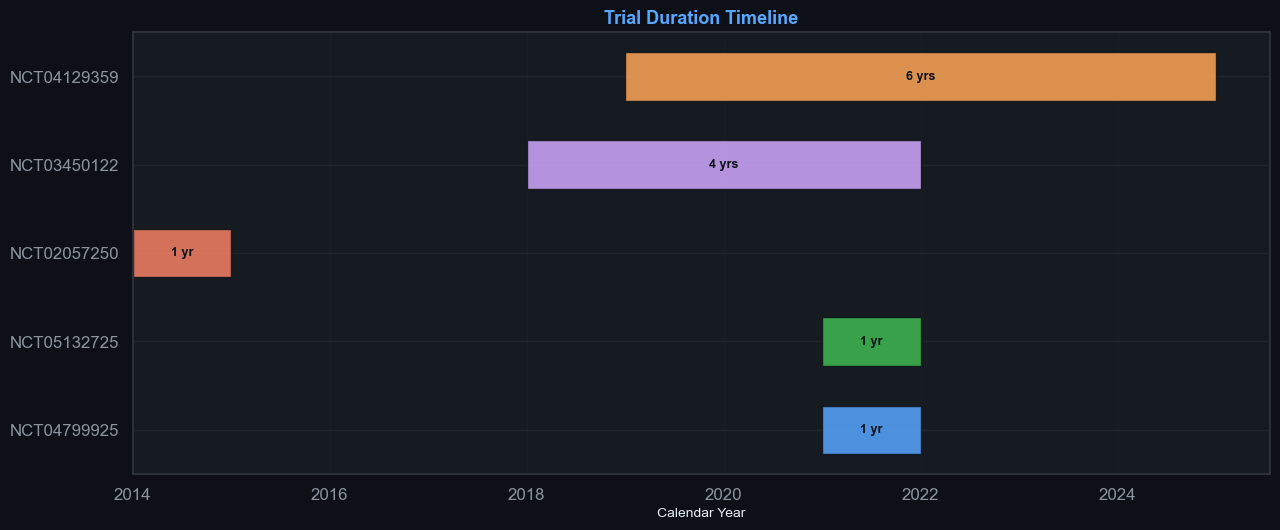

In [19]:
timeline_df = df[["NCT ID", "Short Title", "Start Year", "Duration (yrs)"]].dropna()

fig, ax = plt.subplots(figsize=(13, max(4, len(timeline_df) * 1.1)))

for i, row in timeline_df.iterrows():
    start = row["Start Year"]
    dur   = row["Duration (yrs)"]
    color = COLORS[i % len(COLORS)]
    ax.barh(row["NCT ID"], dur, left=start, color=color,
            edgecolor="#0d1117", alpha=0.85, height=0.55)
    ax.text(start + dur / 2, row["NCT ID"],
            f"{int(dur)} yr{'s' if dur != 1 else ''}",
            va="center", ha="center", fontsize=9,
            color="#0d1117", fontweight="bold")

ax.set_xlabel("Calendar Year", fontsize=10)
ax.set_title("Trial Duration Timeline", fontsize=13,
             fontweight="bold", color="#58a6ff")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()


## 12. Composite Diligence Score

We compute a weighted composite score across all key parameters using **numpy** dot-product.


In [20]:
SCORE_PARAMS = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "# Secondary Endpoints",
    "# Publications", "Has Results",
]

# Weights reflecting diligence importance
WEIGHTS = np.array([
    0.20,   # Phase  — higher phase = later stage = more validated
    0.15,   # Enrollment — bigger trial → more statistical power
    0.10,   # Duration — longer = more thorough (moderate weight)
    0.20,   # Primary endpoints — clearly defined = better design
    0.10,   # Secondary endpoints
    0.15,   # Publications linked
    0.10,   # Results posted
])
assert abs(WEIGHTS.sum() - 1.0) < 1e-9, "Weights must sum to 1"

score_df = df[["NCT ID", "Short Title"] + SCORE_PARAMS].copy()
arr_s = score_df[SCORE_PARAMS].astype(float).values

# Normalize columns 0–1
col_min = arr_s.min(axis=0)
col_max = arr_s.max(axis=0)
arr_norm = (arr_s - col_min) / (col_max - col_min + 1e-9)

# Composite score = weighted dot product
scores = arr_norm @ WEIGHTS          # numpy dot product
score_df["Diligence Score (0–1)"] = scores.round(4)
score_df["Score (%)"] = (scores * 100).round(1)

print("\n🏆  Composite Diligence Scores:")
display(score_df[["NCT ID", "Short Title", "Score (%)"]].sort_values("Score (%)", ascending=False))



🏆  Composite Diligence Scores:


,NCT ID,Short Title,Score (%)
4,NCT04129359,FamilieTrivsel i Almen Praksis: a Mentalisation Program…,45.0
3,NCT03450122,"Modified T Cells, Chemotherapy, and Aldesleukin With or…",40.7
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injec…,37.0
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among Child…,26.7
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy…,4.6


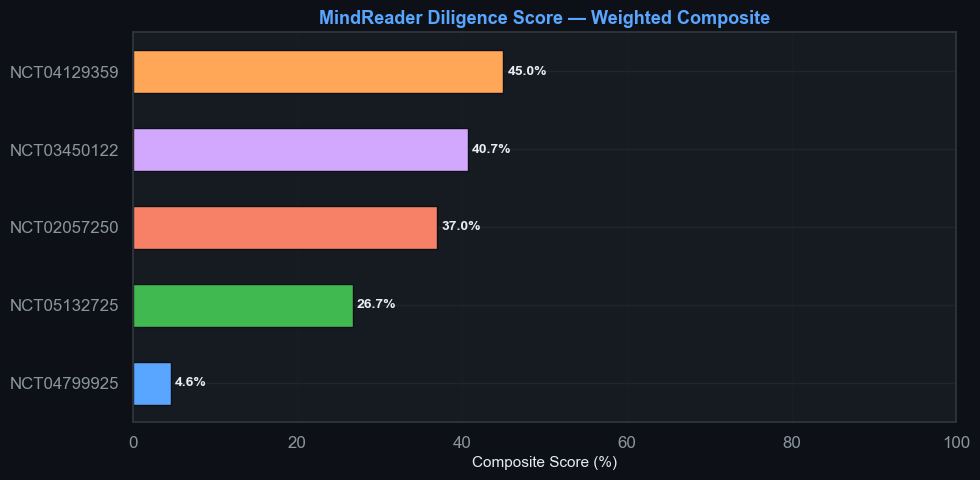

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

sorted_df = score_df.sort_values("Score (%)", ascending=True)
bars = ax.barh(sorted_df["NCT ID"], sorted_df["Score (%)"],
               color=[COLORS[i % len(COLORS)] for i in range(len(sorted_df))],
               edgecolor="#0d1117", height=0.55)

for bar, val in zip(bars, sorted_df["Score (%)"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold", color="#e6edf3")

ax.set_xlim(0, 100)
ax.set_xlabel("Composite Score (%)", fontsize=11)
ax.set_title("MindReader Diligence Score — Weighted Composite",
             fontsize=13, fontweight="bold", color="#58a6ff")
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
plt.show()


## 13. Per-Parameter Score Contribution Breakdown

📊  Per-parameter weighted contributions:


,Phase (numeric),Enrollment,Duration (yrs),# Primary Endpoints,# Secondary Endpoints,# Publications,Has Results,Total
NCT04799925,0.0000,0.0456,0.00,0.0,0.00,0.0,0.0,0.0456
NCT05132725,0.0000,0.0074,0.00,0.2,0.06,0.0,0.0,0.2674
NCT02057250,0.2000,0.0498,0.00,0.0,0.02,0.0,0.1,0.3698
NCT03450122,0.0667,0.0000,0.06,0.2,0.08,0.0,0.0,0.4067
NCT04129359,0.0000,0.1500,0.10,0.1,0.10,0.0,0.0,0.4500


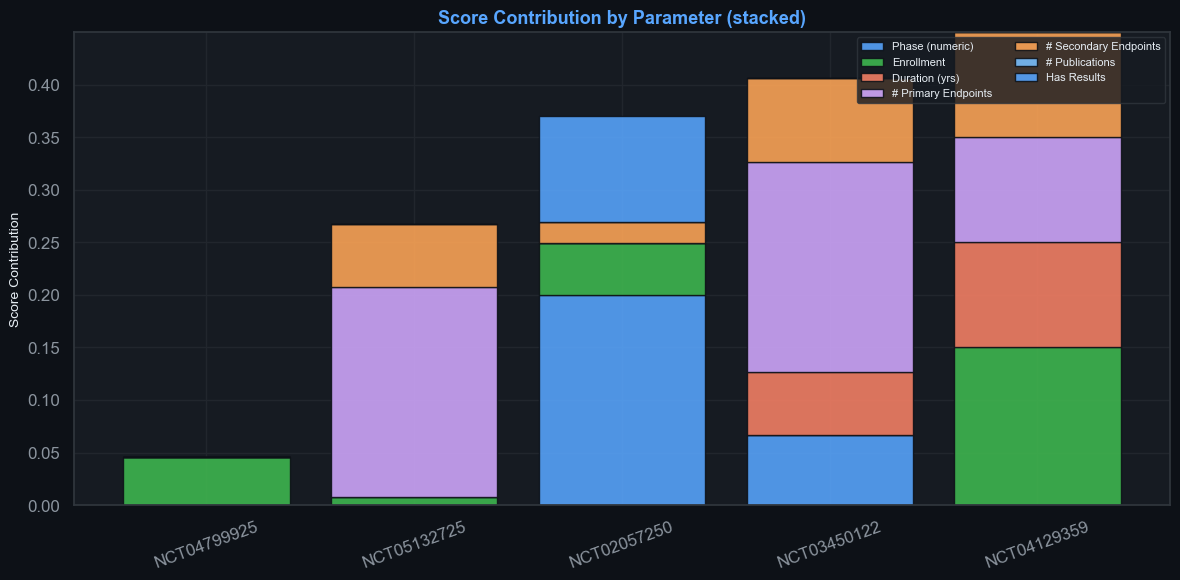

In [22]:
# Show how each parameter contributes to each study's total score
contrib = arr_norm * WEIGHTS
contrib_df = pd.DataFrame(contrib, columns=SCORE_PARAMS, index=score_df["NCT ID"].values)
contrib_df["Total"] = scores

print("📊  Per-parameter weighted contributions:")
display(contrib_df.round(4))

# Stacked bar
contrib_plot = contrib_df[SCORE_PARAMS]
bottom_vals = np.zeros(len(contrib_plot))
fig, ax = plt.subplots(figsize=(12, 6))

for j, col in enumerate(SCORE_PARAMS):
    vals = contrib_plot[col].values
    ax.bar(contrib_plot.index, vals, bottom=bottom_vals,
           label=col, color=COLORS[j % len(COLORS)], edgecolor="#0d1117", alpha=0.88)
    bottom_vals += vals

ax.set_ylabel("Score Contribution", fontsize=10)
ax.set_title("Score Contribution by Parameter (stacked)",
             fontsize=13, fontweight="bold", color="#58a6ff")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 14. Full Combinatorial Summary Table

A pandas pivot/cross-tabulation for **every combination** of categorical parameters.


In [23]:
# All 2-way combinations of categorical variables
cat_combos = list(itertools.combinations(CAT_PARAMS, 2))
print(f"2-way categorical combinations: {len(cat_combos)}")

for (c1, c2) in cat_combos:
    print(f"\n📌  {c1} × {c2}")
    ct = pd.crosstab(df[c1], df[c2], margins=True)
    display(ct)


2-way categorical combinations: 3

📌  Status × Study Type


Study Type,INTERVENTIONAL,OBSERVATIONAL,All
Status,,,
COMPLETED,2,0,2
UNKNOWN,2,1,3
All,4,1,5



📌  Status × Phase (raw)


Phase (raw),NA,PHASE1,PHASE3,All
Status,,,,
COMPLETED,0,1,1,2
UNKNOWN,3,0,0,3
All,3,1,1,5



📌  Study Type × Phase (raw)


Phase (raw),NA,PHASE1,PHASE3,All
Study Type,,,,
INTERVENTIONAL,2,1,1,4
OBSERVATIONAL,1,0,0,1
All,3,1,1,5


## 15. Rank Table — Studies Ranked per Parameter

🏅  Study Rankings per Parameter (1 = best):


,Phase (numeric),Enrollment,Duration (yrs),# Primary Endpoints,# Secondary Endpoints,# Publications,Has Results
NCT ID,,,,,,,
NCT04799925,3,3,3,4,5,1,2
NCT05132725,3,4,3,1,3,1,2
NCT02057250,1,2,3,4,4,1,1
NCT03450122,2,5,2,1,2,1,2
NCT04129359,3,1,1,3,1,1,2


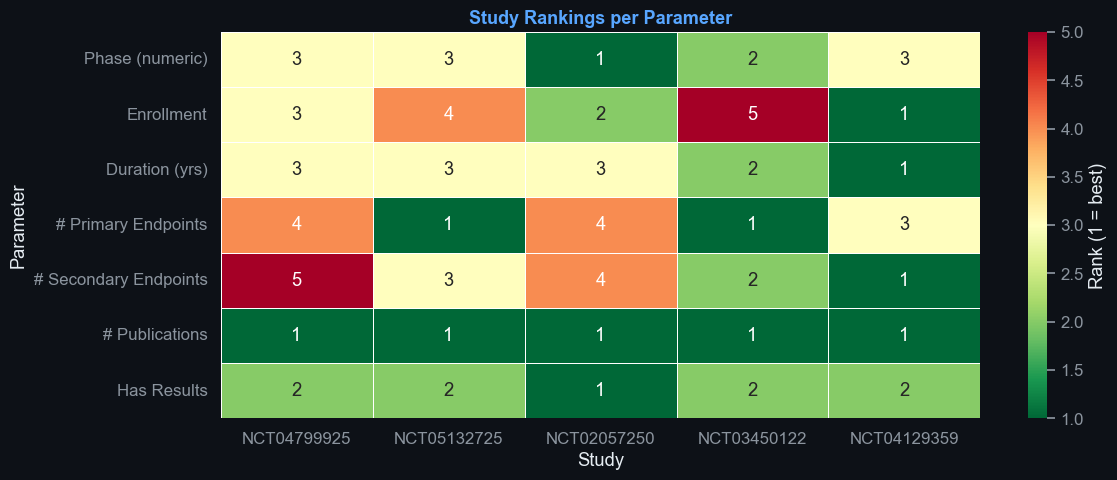

In [24]:
rank_df = df[["NCT ID"] + SCORE_PARAMS].set_index("NCT ID").astype(float)
rank_table = rank_df.rank(ascending=False, method="min").astype(int)

print("🏅  Study Rankings per Parameter (1 = best):")
display(rank_table)

# Heat-map of ranks
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(rank_table.T, annot=True, fmt="d",
            cmap="RdYlGn_r", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Rank (1 = best)"})
ax.set_title("Study Rankings per Parameter", fontsize=13,
             fontweight="bold", color="#58a6ff")
ax.set_xlabel("Study")
ax.set_ylabel("Parameter")
plt.tight_layout()
plt.show()
